In [3]:
# 03 — 因子 EDA（週頻）
# Factor Exploratory Data Analysis (Weekly Frequency)
# This notebook analyzes cryptocurrency factors to understand their characteristics,
# relationships, and predictive power for future returns

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data Loading
# Load the curated factor data that has been processed and cleaned
CUR = Path("../data/curated")
FP = CUR / "factors_weekly.parquet"

df = pd.read_parquet(FP)
df["date_week"] = pd.to_datetime(df["date_week"])
df = df.sort_values(["date_week"])

# Asset Identifier Selection
# Automatically detect which column identifies unique assets (cryptocurrencies)
# This makes the code flexible for different data schemas
ASSET_KEYS = ["market", "symbol", "coingecko_id"]
asset_key = next((k for k in ASSET_KEYS if k in df.columns), None)
if asset_key is None:
    asset_key = "_asset"
    df["_asset"] = "asset_0"

# Factor Selection Strategy
# Define base factors covering different aspects of crypto behavior:
# - Size factors: log_mcap_year, log_price (market cap and price levels)
# - Momentum factors: r1-r4, r4_1, rmom3 (returns over different periods)
# - Volume/Volatility: prcvol_mean_week, prcvol_std_week, vol_4w (trading activity)
base_cols = [
    "log_mcap_year","log_price","max_price_week",
    "r1","r2","r3","r4","r4_1","rmom3",
    "prcvol_mean_week","prcvol_std_week","vol_4w"
]

# Prioritize z-scored factors (cross-sectionally standardized)
# Z-scored factors have mean=0, std=1 within each time period, making cross-asset comparison meaningful
fac_cols = [c+"_z" for c in base_cols if c+"_z" in df.columns]
if not fac_cols:  # Fallback to raw factors if z-scored versions don't exist
    fac_cols = [c for c in base_cols if c in df.columns]

print("asset_key:", asset_key)
print("factors:", fac_cols)
df.head()

asset_key: market
factors: ['log_mcap_year_z', 'log_price_z', 'max_price_week_z', 'r1_z', 'r2_z', 'r3_z', 'r4_z', 'r4_1_z', 'rmom3_z', 'prcvol_mean_week_z', 'prcvol_std_week_z', 'vol_4w_z']


,date_week,market,symbol,close,ret_simple_weekly,log_mcap_year,log_price,max_price_week,r1,r2,...,max_price_week_z,r1_z,r2_z,r3_z,r4_z,r4_1_z,rmom3_z,prcvol_mean_week_z,prcvol_std_week_z,vol_4w_z
1721,2017-08-27,BTC/USDT,BTC,4310.01,0.054749,23.390230,8.368927,4453.91,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3899,2017-08-27,ETH/USDT,ETH,348.13,0.163925,20.255164,5.855444,348.13,NaN,NaN,...,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1722,2017-09-03,BTC/USDT,BTC,4509.08,0.046188,23.390230,8.414070,4939.19,0.054749,NaN,...,1.0,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3900,2017-09-03,ETH/USDT,ETH,341.77,-0.018269,20.255164,5.837060,394.39,0.163925,NaN,...,-1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3901,2017-09-10,ETH/USDT,ETH,293.50,-0.141235,20.255164,5.685279,344.55,-0.018269,0.142661,...,-1.0,-1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# DATA QUALITY ASSESSMENT
# Understanding the dataset dimensions and completeness before analysis

# Basic dataset dimensions
n_assets = df[asset_key].nunique()
n_weeks = df["date_week"].nunique()
print(f"期間週數: {n_weeks}，資產數: {n_assets}，總筆數: {len(df):,}")

# Missing Value Analysis
# High missing ratios (>20%) indicate factors that may be unreliable or have limited coverage
# Factors with <5% missing are generally considered robust for analysis
miss = df[fac_cols].isna().mean().sort_values(ascending=False)
print("\n=== MISSING VALUE INTERPRETATION ===")
print("- Factors with >20% missing: Consider exclusion or special handling")
print("- Factors with 5-20% missing: Usable but may need imputation")
print("- Factors with <5% missing: High quality, ready for analysis")
display(miss.to_frame("missing_ratio"))

# Descriptive Statistics
# For z-scored factors, mean should be ~0, std should be ~1
# Large skewness (>2) or extreme outliers may indicate data quality issues
desc = df[fac_cols].describe().T
print("\n=== DESCRIPTIVE STATISTICS INTERPRETATION ===")
print("For z-scored factors:")
print("- Mean should be close to 0 (cross-sectional standardization)")
print("- Std should be close to 1 (normalized scale)")
print("- Min/Max values show outlier presence (>±3 may be extreme)")
print("- 25%/75% percentiles show distribution shape")
display(desc)

期間週數: 423，資產數: 42，總筆數: 12,061

=== MISSING VALUE INTERPRETATION ===
- Factors with >20% missing: Consider exclusion or special handling
- Factors with 5-20% missing: Usable but may need imputation
- Factors with <5% missing: High quality, ready for analysis


,missing_ratio
log_mcap_year_z,0.531548
r4_1_z,0.013929
r4_z,0.013929
r3_z,0.010447
prcvol_std_week_z,0.010447
prcvol_mean_week_z,0.010447
vol_4w_z,0.010447
rmom3_z,0.010447
r2_z,0.006965
r1_z,0.003482



=== DESCRIPTIVE STATISTICS INTERPRETATION ===
For z-scored factors:
- Mean should be close to 0 (cross-sectional standardization)
- Std should be close to 1 (normalized scale)
- Min/Max values show outlier presence (>±3 may be extreme)
- 25%/75% percentiles show distribution shape


,count,mean,std,min,25%,50%,75%,max
log_mcap_year_z,5650.0,2.010584e-16,1.000089,-1.245169,-0.678387,-0.352465,0.312674,2.764364
log_price_z,12061.0,7.695435e-18,1.000041,-1.582122,-0.839230,-0.237212,0.534926,3.141169
max_price_week_z,12061.0,6.627648e-19,1.000041,-1.000000,-0.207510,-0.198491,-0.188179,6.054062
r1_z,12019.0,-6.724706e-18,1.000042,-4.898110,-0.589766,-0.161829,0.402612,6.082763
r2_z,11977.0,-7.786485e-19,1.000042,-4.195885,-0.591479,-0.175815,0.392916,6.082763
r3_z,11935.0,1.138595e-17,1.000042,-3.811120,-0.597068,-0.195900,0.388180,6.082763
r4_z,11893.0,-4.219464e-18,1.000042,-3.876383,-0.605732,-0.207596,0.372921,6.082763
r4_1_z,11893.0,-4.219464e-18,1.000042,-3.876383,-0.605732,-0.207596,0.372921,6.082763
rmom3_z,11935.0,-4.297638e-18,1.000042,-5.915057,-0.527383,-0.055337,0.494576,5.894171
prcvol_mean_week_z,11935.0,6.697617e-19,1.000042,-1.000000,-0.399072,-0.305878,-0.127448,5.974577


In [ ]:
# CROSS-SECTIONAL CORRELATION ANALYSIS
# Calculate week-by-week correlations between factors, then average over time
# This shows how factors relate to each other within each time period

cs_corr_list = []
for d, g in df.groupby("date_week"):
    if len(g) < 5:  # Skip weeks with too few assets
        continue
    cs_corr_list.append(g[fac_cols].corr())

if cs_corr_list:
    # Average correlation matrix across all time periods
    cs_corr_avg = sum(cs_corr_list) / len(cs_corr_list)
    
    print("=== CORRELATION INTERPRETATION ===")
    print("- High correlations (>0.7): Factors may be redundant")
    print("- Moderate correlations (0.3-0.7): Related but distinct factors")
    print("- Low correlations (<0.3): Independent factors")
    print("- Negative correlations: Factors move in opposite directions")
    display(cs_corr_avg)
else:
    print("有效週數不足以計算平均相關")

,log_mcap_year_z,log_price_z,max_price_week_z,r1_z,r2_z,r3_z,r4_z,r4_1_z,rmom3_z,prcvol_mean_week_z,prcvol_std_week_z,vol_4w_z
log_mcap_year_z,1.000000,0.712232,0.727050,0.064775,0.082051,0.090205,0.102278,0.102278,0.078989,0.865548,0.788663,-0.270110
log_price_z,0.712232,1.000000,0.602191,0.041836,0.051462,0.058163,0.060461,0.060461,0.081891,0.641425,0.545571,-0.170242
max_price_week_z,0.727050,0.602191,1.000000,0.026685,0.036438,0.043066,0.047783,0.047783,0.058697,0.854543,0.715412,-0.174421
r1_z,0.064775,0.041836,0.026685,1.000000,0.677978,0.551870,0.471592,0.471592,0.403958,0.066514,0.115648,0.175994
r2_z,0.082051,0.051462,0.036438,0.677978,1.000000,0.799073,0.685773,0.685773,0.536514,0.099686,0.165802,0.291656
r3_z,0.090205,0.058163,0.043066,0.551870,0.799073,1.000000,0.852951,0.852951,0.638862,0.130142,0.211831,0.380419
r4_z,0.102278,0.060461,0.047783,0.471592,0.685773,0.852951,1.000000,1.000000,0.522617,0.147861,0.234791,0.355288
r4_1_z,0.102278,0.060461,0.047783,0.471592,0.685773,0.852951,1.000000,1.000000,0.522617,0.147861,0.234791,0.355288
rmom3_z,0.078989,0.081891,0.058697,0.403958,0.536514,0.638862,0.522617,0.522617,1.000000,0.110121,0.135434,0.203303
prcvol_mean_week_z,0.865548,0.641425,0.854543,0.066514,0.099686,0.130142,0.147861,0.147861,0.110121,1.000000,0.917430,-0.113149


=== DISTRIBUTION INTERPRETATION ===
For z-scored factors, expect:
- Approximately normal distribution centered at 0
- Standard deviation around 1
- Outliers beyond ±3 are unusual
- Skewed distributions may indicate data issues or factor transformation needs


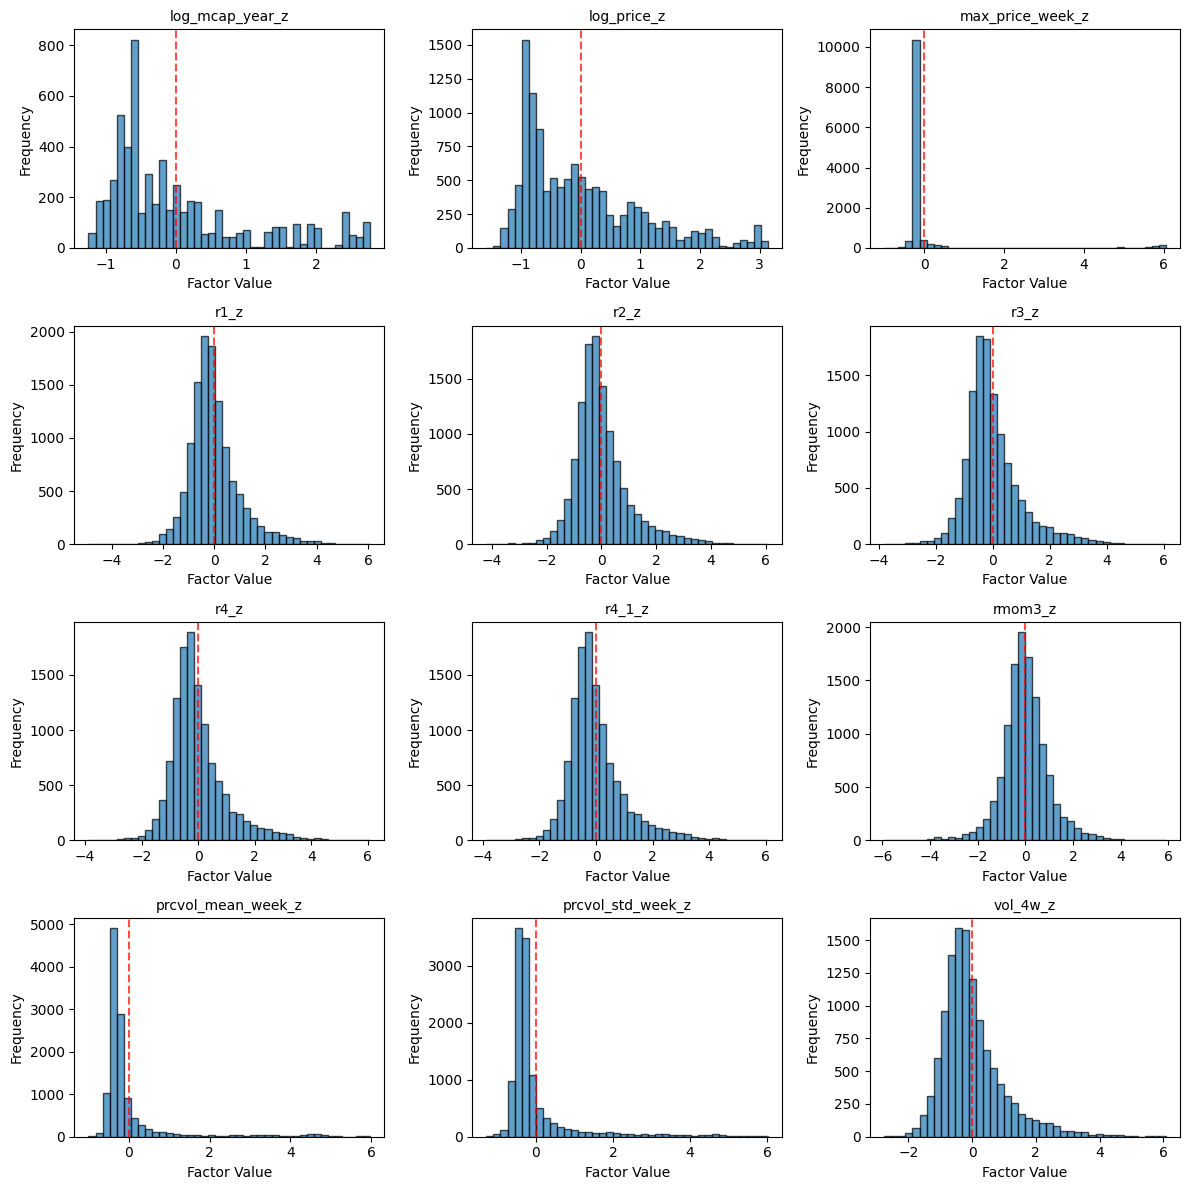

In [6]:
# FACTOR DISTRIBUTION ANALYSIS
# Visualize the distribution of each factor to understand their characteristics
# This helps identify outliers, skewness, and normality

print("=== DISTRIBUTION INTERPRETATION ===")
print("For z-scored factors, expect:")
print("- Approximately normal distribution centered at 0")
print("- Standard deviation around 1")
print("- Outliers beyond ±3 are unusual")
print("- Skewed distributions may indicate data issues or factor transformation needs")

import math

k = len(fac_cols)
cols = 3
rows = math.ceil(k/cols)
plt.figure(figsize=(cols*4, rows*3))
for i, c in enumerate(fac_cols, 1):
    plt.subplot(rows, cols, i)
    x = df[c].dropna()
    if len(x) > 0:
        plt.hist(x, bins=40, alpha=0.7, edgecolor='black')
        plt.axvline(0, color='red', linestyle='--', alpha=0.7, label='Mean=0')
    plt.title(c, fontsize=10)
    plt.xlabel('Factor Value')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

=== TIME SERIES INTERPRETATION ===
- Stable factors: Mean oscillates around 0 with consistent dispersion
- Trending factors: Mean shows persistent upward/downward movement
- Regime changes: Sudden shifts in mean or dispersion
- High volatility: Large swings in cross-sectional means


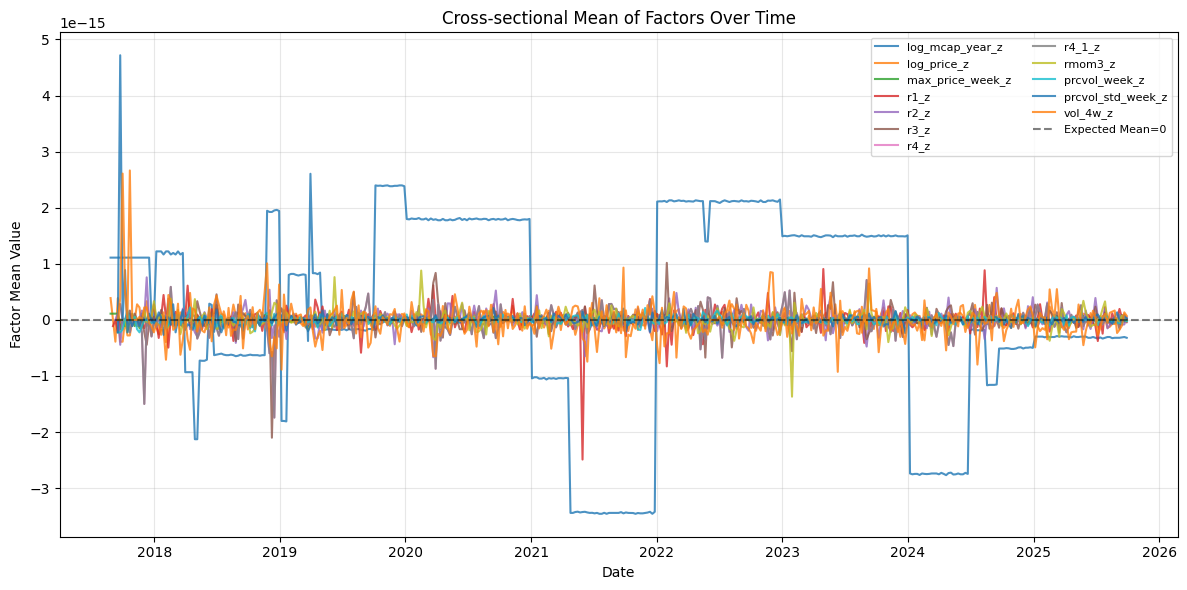

In [7]:
# TIME SERIES STABILITY ANALYSIS
# Examine factor stability over time by tracking cross-sectional means and dispersion
# This reveals whether factors maintain consistent behavior across market cycles

# Calculate weekly cross-sectional statistics for each factor
stat_ts = (
    df.groupby("date_week")[fac_cols]
      .agg(["mean", lambda s: s.quantile(0.75)-s.quantile(0.25)])
)
# Flatten column names for easier access
stat_ts.columns = [f"{a}_{b}" if isinstance(b, str) else f"{a}_IQR" for a,b in stat_ts.columns]
stat_ts = stat_ts.reset_index()

print("=== TIME SERIES INTERPRETATION ===")
print("- Stable factors: Mean oscillates around 0 with consistent dispersion")
print("- Trending factors: Mean shows persistent upward/downward movement")
print("- Regime changes: Sudden shifts in mean or dispersion")
print("- High volatility: Large swings in cross-sectional means")

# Plot cross-sectional means over time
fig, ax = plt.subplots(figsize=(12, 6))
for c in [f"{f}_mean" for f in fac_cols if f"{f}_mean" in stat_ts.columns]:
    ax.plot(stat_ts["date_week"], stat_ts[c], label=c.replace("_mean", ""), alpha=0.8)
ax.axhline(0, color='black', linestyle='--', alpha=0.5, label='Expected Mean=0')
ax.set_title("Cross-sectional Mean of Factors Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Factor Mean Value")
ax.legend(loc="best", ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== PCA INTERPRETATION ===
- Explained variance ratio: How much total variation each PC captures
- Component loadings: How much each original factor contributes to each PC
- High loadings (>0.3): Strong contribution to that principal component
- PC1 usually captures the dominant market factor
- PC2-PC3 often capture style factors (size, momentum, volatility)

Explained variance ratio: [0.39877481 0.30746672 0.07520805 0.05658108 0.05261938 0.02967477]
Cumulative explained variance: [0.39877481 0.70624153 0.78144958 0.83803067 0.89065005 0.92032482]

=== COMPONENT LOADINGS ===


,log_mcap_year_z,log_price_z,max_price_week_z,r1_z,r2_z,r3_z,r4_z,r4_1_z,rmom3_z,prcvol_mean_week_z,prcvol_std_week_z,vol_4w_z
PC1,0.264850,0.254141,0.257647,0.246116,0.314617,0.347466,0.346201,0.346201,0.256186,0.316473,0.329094,0.069252
PC2,0.363159,0.328932,0.355928,-0.207770,-0.261991,-0.278935,-0.266657,-0.266657,-0.181890,0.356131,0.286799,-0.243401
PC3,-0.020408,-0.032227,0.006133,-0.425492,-0.204388,0.006911,0.114745,0.114745,-0.216656,0.094250,0.209835,0.805887
PC4,0.011501,0.017339,0.036231,0.671729,0.256671,-0.107557,-0.332754,-0.332754,-0.243566,0.035370,0.080981,0.425443
PC5,-0.008887,0.090962,0.015359,-0.104358,-0.076833,0.000461,-0.290240,-0.290240,0.860963,-0.001250,-0.035548,0.252222
PC6,-0.058319,0.884800,-0.278165,-0.020279,0.019949,0.003234,0.041603,0.041603,-0.099887,-0.165593,-0.294898,0.087798



=== PC1 LOADINGS (Ordered by Absolute Value) ===


,Loading
Factor,
r3_z,0.347466
r4_z,0.346201
r4_1_z,0.346201
prcvol_std_week_z,0.329094
prcvol_mean_week_z,0.316473
r2_z,0.314617
log_mcap_year_z,0.264850
max_price_week_z,0.257647
rmom3_z,0.256186


Strong contributors (|loading| > 0.3): r3_z, r4_z, r4_1_z

=== PC2 LOADINGS (Ordered by Absolute Value) ===


...

Strong contributors (|loading| > 0.3): r1_z, vol_4w_z, r4_1_z

=== PC5 LOADINGS (Ordered by Absolute Value) ===


,Loading
Factor,
rmom3_z,0.860963
r4_z,-0.290240
r4_1_z,-0.290240
vol_4w_z,0.252222
r1_z,-0.104358
log_price_z,0.090962
r2_z,-0.076833
prcvol_std_week_z,-0.035548
max_price_week_z,0.015359


Strong contributors (|loading| > 0.3): rmom3_z

=== PC6 LOADINGS (Ordered by Absolute Value) ===


,Loading
Factor,
log_price_z,0.884800
prcvol_std_week_z,-0.294898
max_price_week_z,-0.278165
prcvol_mean_week_z,-0.165593
rmom3_z,-0.099887
vol_4w_z,0.087798
log_mcap_year_z,-0.058319
r4_1_z,0.041603
r4_z,0.041603


Strong contributors (|loading| > 0.3): log_price_z


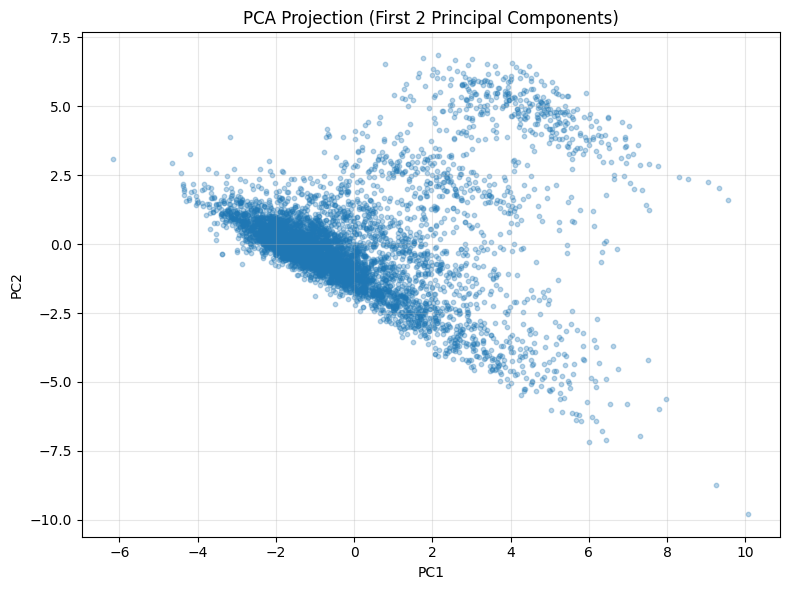

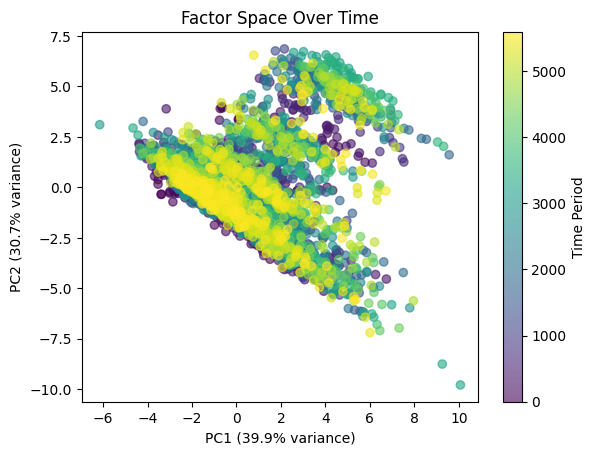

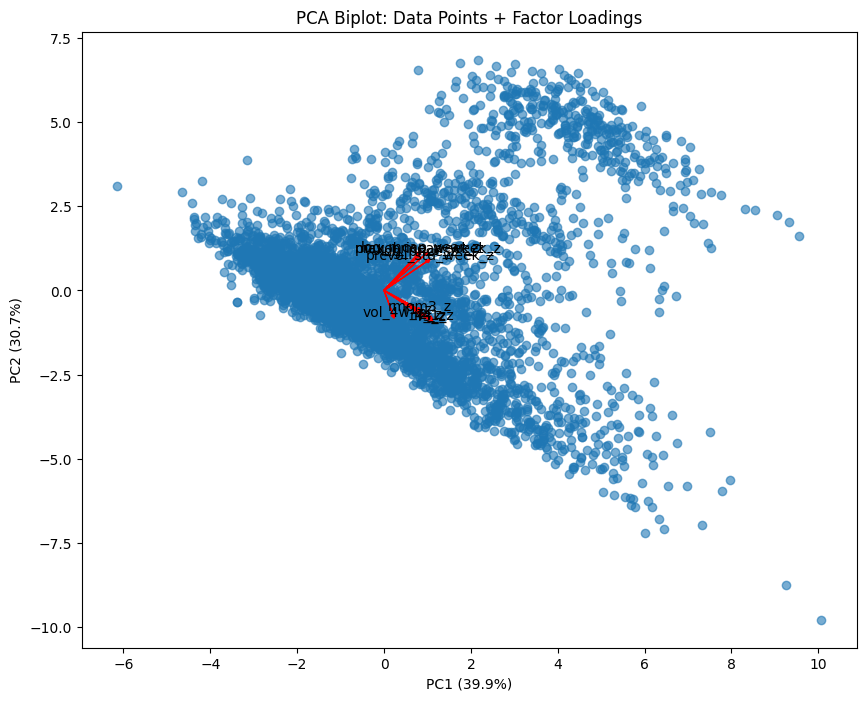

In [12]:
# PRINCIPAL COMPONENT ANALYSIS (PCA)
# Identify underlying factor structure and reduce dimensionality
# This reveals which factors capture similar information and the main drivers of variation

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df[fac_cols].dropna()
if len(X) < 100:
    print("有效資料不足以做 PCA（<100 列）。")
else:
    print("=== PCA INTERPRETATION ===")
    print("- Explained variance ratio: How much total variation each PC captures")
    print("- Component loadings: How much each original factor contributes to each PC")
    print("- High loadings (>0.3): Strong contribution to that principal component")
    print("- PC1 usually captures the dominant market factor")
    print("- PC2-PC3 often capture style factors (size, momentum, volatility)")
    
    # Apply PCA (data is already z-scored, but standardize for consistency)
    Xs = StandardScaler(with_mean=True, with_std=True).fit_transform(X)

    pca = PCA(n_components=min(len(fac_cols), 6))
    pca.fit(Xs)
    print(f"\nExplained variance ratio: {pca.explained_variance_ratio_}")
    print(f"Cumulative explained variance: {pca.explained_variance_ratio_.cumsum()}")

    # Display component loadings
    comp = pd.DataFrame(pca.components_, columns=fac_cols)
    comp.index = [f"PC{i+1}" for i in range(len(comp))]
    print("\n=== COMPONENT LOADINGS ===")
    display(comp)

    # Display component loadings ordered by magnitude for each PC
    for i in range(min(len(fac_cols), 6)):
        print(f"\n=== PC{i+1} LOADINGS (Ordered by Absolute Value) ===")
        
        # Get loadings for this PC and sort by absolute value
        pc_loadings = comp.iloc[i].abs().sort_values(ascending=False)
        
        # Create a dataframe with original values (preserving sign) and absolute values
        loading_df = pd.DataFrame({
            'Factor': pc_loadings.index,
            'Loading': [comp.iloc[i][factor] for factor in pc_loadings.index],
            'Abs_Loading': pc_loadings.values
        })
        
        display(loading_df[['Factor', 'Loading']].set_index('Factor'))
    
        # Optional: Show interpretation
        strong_factors = loading_df[loading_df['Abs_Loading'] > 0.3]['Factor'].tolist()
        if strong_factors:
            print(f"Strong contributors (|loading| > 0.3): {', '.join(strong_factors[:3])}")

    # Plot the data on the PCAs
    # Project data onto the first two principal components
    X_pca = pca.transform(Xs)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=10)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Projection (First 2 Principal Components)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Add these after your existing plotting code:

    # 1. Color by time to see temporal patterns
    dates = X.index  # assuming your dataframe has date index
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=range(len(dates)), cmap='viridis', alpha=0.6)
    plt.colorbar(label='Time Period')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.title('Factor Space Over Time')

    # 2. Biplot to show factor contributions
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)

    # Plot factor loadings as arrows
    for i, factor in enumerate(fac_cols):
        ax.arrow(0, 0, comp.iloc[0, i]*3, comp.iloc[1, i]*3, 
                 head_width=0.1, head_length=0.1, fc='red', ec='red')
        ax.text(comp.iloc[0, i]*3.2, comp.iloc[1, i]*3.2, factor, 
                fontsize=10, ha='center')

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.set_title('PCA Biplot: Data Points + Factor Loadings')

In [ ]:
# INFORMATION COEFFICIENT (IC) ANALYSIS
# Measure predictive power of factors by correlating current factor values with next period returns
# IC is a key metric for factor effectiveness in quantitative finance

print("=== INFORMATION COEFFICIENT INTERPRETATION ===")
print("- IC measures correlation between factor(t) and return(t+1)")
print("- |IC| > 0.05: Potentially useful factor")
print("- |IC| > 0.10: Strong factor") 
print("- Positive IC: Higher factor values predict higher returns")
print("- Negative IC: Higher factor values predict lower returns")
print("- Consistent IC sign across time indicates robust factor")

# Create forward returns (next week's return for each asset)
df2 = df.sort_values([asset_key, "date_week"]).copy()
df2["ret_fwd1"] = df2.groupby(asset_key)["ret_simple_weekly"].shift(-1)

# Calculate weekly cross-sectional correlations between factors and forward returns
rows = []
for d, g in df2.groupby("date_week"):
    g = g.dropna(subset=["ret_fwd1"])
    if len(g) < 5:  # Need minimum assets for reliable correlation
        continue
    row = {"date_week": d}
    for c in fac_cols:
        x = g[c]; y = g["ret_fwd1"]
        m = x.notna() & y.notna()
        row[c] = np.corrcoef(x[m], y[m])[0,1] if m.sum() >= 5 else np.nan
    rows.append(row)

ic_df = pd.DataFrame(rows).set_index("date_week")
print("\n=== FACTOR RANKING BY PREDICTIVE POWER ===")
display(ic_df.mean().sort_values(ascending=False).to_frame("IC_mean"))

,IC_mean
log_mcap_year_z,0.067161
prcvol_mean_week_z,0.036907
prcvol_std_week_z,0.029028
max_price_week_z,0.028735
log_price_z,0.021144
r2_z,0.020951
r3_z,0.020146
r1_z,0.019717
rmom3_z,0.015840
r4_z,0.014397


In [ ]:
# EXPORT RESULTS FOR DOWNSTREAM ANALYSIS
# Save key metrics to files for use in factor modeling and portfolio construction

OUT = Path("../data/metrics")
OUT.mkdir(parents=True, exist_ok=True)

print("=== OUTPUT FILES ===")

# Export average cross-sectional correlation matrix
# Use this to identify redundant factors and understand factor relationships
if 'cs_corr_avg' in globals():
    cs_corr_avg.to_csv(OUT / "factor_cs_avg_corr.csv")
    print("✓ factor_cs_avg_corr.csv: Average correlation matrix for factor selection")

# Export Information Coefficient rankings
# Use this to prioritize factors by predictive power in ML models
ic_mean = ic_df.mean().to_frame("IC_mean")
ic_mean.to_csv(OUT / "factor_ic_mean_quick.csv")
print("✓ factor_ic_mean_quick.csv: Factor rankings by predictive power")

print("\n=== NEXT STEPS ===")
print("1. Use high-IC factors for ML model features")
print("2. Remove highly correlated factors (>0.7) to reduce redundancy")
print("3. Consider factor stability over time for robust model building")
print("4. Investigate factors with regime changes for conditional models")

print("\n已輸出到 data/metrics/ ：factor_cs_avg_corr.csv, factor_ic_mean_quick.csv")

已輸出到 data/metrics/ ：factor_cs_avg_corr.csv, factor_ic_mean_quick.csv


## <hr>
### Merged from: `unsupervised_eda.ipynb`
## <hr>

# Unsupervised learning
Performing some EDA on the Bitcoin dataset wit unsupervised learning algorithms.

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# Importing data

In [45]:
from pathlib import Path
import pandas as pd
import numpy as np

CUR = Path("../data/curated")

# Load factor data (same as factor model, but we'll use it differently)
fp = CUR / "factors_weekly.parquet"
df = pd.read_parquet(fp)
display(df.head())
print(df.columns)

print(df["symbol"].value_counts().head(10))
print(df["symbol"].unique())
print(df[["symbol", "date_week", "log_price"]].head(20))

,date_week,market,symbol,close,ret_simple_weekly,log_mcap_year,log_price,max_price_week,r1,r2,...,max_price_week_z,r1_z,r2_z,r3_z,r4_z,r4_1_z,rmom3_z,prcvol_mean_week_z,prcvol_std_week_z,vol_4w_z
0,2018-04-29,ADA/USDT,ADA,0.36254,0.287429,23.649626,0.309351,0.38660,NaN,NaN,...,-0.459929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-05-06,ADA/USDT,ADA,0.34654,-0.044133,23.649626,0.297538,0.38850,0.287429,NaN,...,-0.465840,1.555026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-05-13,ADA/USDT,ADA,0.27718,-0.200150,23.649626,0.244655,0.34740,-0.044133,0.230611,...,-0.429362,-0.707030,0.912299,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-05-20,ADA/USDT,ADA,0.25556,-0.078000,23.649626,0.227582,0.27815,-0.200150,-0.235450,...,-0.429236,-0.828085,-0.912777,-0.121917,NaN,NaN,-0.062947,-0.507766,-0.430727,1.444747
4,2018-05-27,ADA/USDT,ADA,0.19186,-0.249257,23.649626,0.175515,0.25999,-0.078000,-0.262538,...,-0.428683,-1.288117,-1.050748,-1.154736,-0.661827,-0.661827,-1.327151,-0.526044,-0.506106,-0.241310


Index(['date_week', 'market', 'symbol', 'close', 'ret_simple_weekly',
       'log_mcap_year', 'log_price', 'max_price_week', 'r1', 'r2', 'r3', 'r4',
       'r4_1', 'rmom3', 'prcvol_mean_week', 'prcvol_std_week', 'vol_4w',
       'log_mcap_year_z', 'log_price_z', 'max_price_week_z', 'r1_z', 'r2_z',
       'r3_z', 'r4_z', 'r4_1_z', 'rmom3_z', 'prcvol_mean_week_z',
       'prcvol_std_week_z', 'vol_4w_z'],
      dtype='object')
symbol
BTC      423
ETH      423
BNB      411
NEO      409
LTC      406
QTUM     392
ADA      388
XRP      386
MIOTA    382
XLM      382
Name: count, dtype: int64
['ADA' 'ATOM' 'AVAX' 'BCC' 'BNB' 'BSV' 'BTC' 'BTG' 'DASH' 'DOGE' 'DOT'
 'EOS' 'ETC' 'ETH' 'HBAR' 'ICP' 'MIOTA' 'LINK' 'LSK' 'LTC' 'LUNA' 'MATIC'
 'MKR' 'NANO' 'NEO' 'QTUM' 'REP' 'SHIB' 'SOL' 'STEEM' 'SUI' 'TON' 'TRX'
 'UNI' 'WAVES' 'XEM' 'XLM' 'XMR' 'XRP' 'XTZ' 'XVG' 'ZEC']
   symbol  date_week  log_price
0     ADA 2018-04-29   0.309351
1     ADA 2018-05-06   0.297538
2     ADA 2018-05-13   0.244655
3     

In [ ]:
# Turn dataframe into wide frame
price_pivot = df.pivot(index="date_week", columns="symbol", values="log_price")
display(price_pivot.head())

returns = price_pivot.pct_change(fill_method=None).dropna(how="all")
display(returns.head())

symbol,ADA,ATOM,AVAX,BCC,BNB,BSV,BTC,BTG,DASH,DOGE,...,TRX,UNI,WAVES,XEM,XLM,XMR,XRP,XTZ,XVG,ZEC
date_week,,,,,,,,,,,,,,,,,,,,,
2017-08-27,NaN,NaN,NaN,NaN,NaN,NaN,8.368927,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-03,NaN,NaN,NaN,NaN,NaN,NaN,8.414070,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-10,NaN,NaN,NaN,NaN,NaN,NaN,8.326364,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-17,NaN,NaN,NaN,NaN,NaN,NaN,8.216356,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-24,NaN,NaN,NaN,NaN,NaN,NaN,8.205497,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31,0.594045,1.698730,3.194583,6.301153,6.755361,NaN,11.592174,NaN,3.202746,0.193682,...,0.293416,2.362645,NaN,NaN,0.302177,NaN,1.328586,0.542266,0.005369,3.724005
2025-09-07,0.607099,1.701835,3.245712,6.403905,6.781114,NaN,11.618531,NaN,3.243373,0.206014,...,0.286081,2.341421,NaN,NaN,0.308660,NaN,1.355062,0.536376,0.005602,3.899950
2025-09-14,0.635465,1.728997,3.415758,6.401254,6.832504,NaN,11.655024,NaN,3.228430,0.245265,...,0.298993,2.343151,NaN,NaN,0.329016,NaN,1.393245,0.570301,0.005932,3.940999


symbol,ADA,ATOM,AVAX,BCC,BNB,BSV,BTC,BTG,DASH,DOGE,...,TRX,UNI,WAVES,XEM,XLM,XMR,XRP,XTZ,XVG,ZEC
date_week,,,,,,,,,,,,,,,,,,,,,
2017-09-03,NaN,NaN,NaN,NaN,NaN,NaN,0.005394,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-10,NaN,NaN,NaN,NaN,NaN,NaN,-0.010424,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-17,NaN,NaN,NaN,NaN,NaN,NaN,-0.013212,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-24,NaN,NaN,NaN,NaN,NaN,NaN,-0.001322,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-10-01,NaN,NaN,NaN,NaN,NaN,NaN,0.021838,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# Performing KMeans-clustering
X = returns.T
display(X.head())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

date_week,2024-08-25,2024-09-01,2024-09-08,2024-09-15,2024-09-22,2024-09-29,2024-10-06,2024-10-13,2024-10-20,2024-10-27,...,2025-07-27,2025-08-03,2025-08-10,2025-08-17,2025-08-24,2025-08-31,2025-09-07,2025-09-14,2025-09-21,2025-09-28
symbol,,,,,,,,,,,,,,,,,,,,,
ADA,0.151706,-0.139777,0.023860,-0.001475,0.038996,0.130225,-0.100629,-0.024895,0.046758,-0.068512,...,-0.030303,-0.126202,0.102338,0.199027,-0.054012,-0.107481,0.029336,0.063226,-0.004392,-0.124661
ATOM,0.108605,-0.150701,-0.114419,0.066176,0.131281,0.094274,-0.075010,-0.066466,0.081567,-0.051129,...,-0.057982,-0.123307,0.091037,-0.008580,0.036564,-0.067627,0.003806,0.033675,-0.050701,-0.081364
AVAX,0.292988,-0.204309,0.085434,0.023656,0.146639,0.064126,-0.072314,0.078693,-0.003441,-0.110152,...,0.040735,-0.179969,0.115115,0.051616,0.030726,-0.094077,0.054701,0.192869,0.122283,-0.140436
BCC,0.069649,-0.122369,-0.023345,0.036018,0.082807,0.029189,-0.079410,-0.010166,0.151261,-0.047851,...,0.076642,-0.077627,0.048328,0.020158,0.002062,-0.066872,0.108416,-0.002653,-0.013298,-0.088443
BNB,0.080384,-0.107162,-0.018150,0.099980,0.063787,0.011721,-0.042478,0.003332,0.058895,-0.027562,...,0.115193,-0.109941,0.074560,0.059662,0.024702,-0.021517,0.026118,0.052792,0.130911,-0.074165


In [68]:
def perform_clustering(X_scaled, symbols, num_clusters: int = 5):
    """
    Perform K-means clustering on scaled data
    
    Parameters:
    - X_scaled: numpy array of scaled features
    - symbols: list or index of symbol names
    - num_clusters: number of clusters to create
    """
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    clusters = pd.DataFrame({"symbol": symbols, "cluster": kmeans.labels_})

    # Calculate silhuette
    silhouette_avg = silhouette_score(X_scaled, labels)

    return clusters, silhouette_avg

In [69]:
clusters = perform_clustering(X_scaled, X.index)
display(clusters)

(   symbol  cluster
 0     ADA        0
 1    ATOM        1
 2    AVAX        1
 3     BCC        0
 4     BNB        2
 5     BSV        2
 6     BTC        2
 7     BTG        2
 8    DASH        0
 9    DOGE        0
 10    DOT        1
 11    EOS        0
 12    ETC        1
 13    ETH        0
 14   HBAR        1
 15    ICP        1
 16   LINK        1
 17    LSK        1
 18    LTC        0
 19   LUNA        1
 20  MATIC        2
 21  MIOTA        1
 22    MKR        0
 23   NANO        2
 24    NEO        1
 25   QTUM        1
 26    REP        2
 27   SHIB        0
 28    SOL        0
 29  STEEM        0
 30    SUI        4
 31    TON        0
 32    TRX        2
 33    UNI        1
 34  WAVES        2
 35    XEM        2
 36    XLM        1
 37    XMR        2
 38    XRP        0
 39    XTZ        1
 40    XVG        1
 41    ZEC        3,
 0.18457414724606272)

In [70]:
# Try out different number of clusters
display(X.__len__())
n_clusters = [2,4,6,8,10,12,16,20,25,30,40]

silhouette_scores = []

for num_cluster in n_clusters:
    res, silhouette_avg = perform_clustering(X_scaled, X.index, num_clusters=num_cluster)
    silhouette_scores.append(silhouette_avg)
    print(f"NUM_CLUSTERS: {num_cluster}, SCORE: {silhouette_avg}")

best = max(silhouette_scores)
best_num_clusters = n_clusters[silhouette_scores.index(best)]
print(f"BEST SILHOUETTE SCORE: {best}, CLUSTER: {best_num_clusters}")

42

NUM_CLUSTERS: 2, SCORE: 0.22506945182060636
NUM_CLUSTERS: 4, SCORE: 0.17308518804428982
NUM_CLUSTERS: 6, SCORE: 0.1997500923554527
NUM_CLUSTERS: 8, SCORE: 0.19294688163512805
NUM_CLUSTERS: 10, SCORE: 0.1725207356008569
NUM_CLUSTERS: 12, SCORE: 0.1745195513341491
NUM_CLUSTERS: 16, SCORE: 0.17861803127027928
NUM_CLUSTERS: 20, SCORE: 0.17352977188589164
NUM_CLUSTERS: 25, SCORE: 0.1797956802948996
NUM_CLUSTERS: 30, SCORE: 0.17392269093165927
NUM_CLUSTERS: 40, SCORE: 0.16666666666666666
BEST SILHOUETTE SCORE: 0.22506945182060636, CLUSTER: 2


/home/jannis/Desktop/university/WS25/FinTech/project/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (36) found smaller than n_clusters (40). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


=> mainly two classes of cryptocurrencies which tend to move similarly!

In [71]:
res1, _ = perform_clustering(X_scaled, X.index, num_clusters=best_num_clusters)
display(res1)
kmeans_clusters = res1.groupby("cluster")["symbol"].apply(list)
print(kmeans_clusters)

,symbol,cluster
0,ADA,0
1,ATOM,0
2,AVAX,0
3,BCC,1
4,BNB,1
5,BSV,1
6,BTC,1
7,BTG,1
8,DASH,0
9,DOGE,0


cluster
0    [ADA, ATOM, AVAX, DASH, DOGE, DOT, ETC, ETH, H...
1    [BCC, BNB, BSV, BTC, BTG, EOS, MATIC, NANO, RE...
Name: symbol, dtype: object


In [ ]:
feature_cols = [
    'ret_simple_weekly',     # Weekly returns
    'log_mcap_year',         # Market cap (size)
    'log_price',            # Price level
    'max_price_week',       # Price momentum
    'r1', 'r2', 'r3', 'r4', # Recent returns (momentum)
    'r4_1',                 # Reversal patterns
    'rmom3',                # 3-period momentum
    'prcvol_mean_week',     # Trading volume
    'prcvol_std_week',      # Volume volatility
    'vol_4w'                # 4-week volatility
]

In [72]:
def create_style_features(df):
    """Create style-based features for clustering"""
    
    # Calculate rolling statistics for each crypto
    style_features = []
    
    for symbol in df['symbol'].unique():
        symbol_data = df[df['symbol'] == symbol].sort_values('date_week')
        
        if len(symbol_data) < 12:  # Skip cryptos with insufficient data
            continue
            
        # Calculate style characteristics
        features = {
            'symbol': symbol,
            'avg_return': symbol_data['ret_simple_weekly'].mean(),
            'volatility': symbol_data['ret_simple_weekly'].std(),
            'sharpe_ratio': symbol_data['ret_simple_weekly'].mean() / symbol_data['ret_simple_weekly'].std(),
            'max_drawdown': (symbol_data['ret_simple_weekly'].cumsum().expanding().max() - 
                           symbol_data['ret_simple_weekly'].cumsum()).max(),
            'skewness': symbol_data['ret_simple_weekly'].skew(),
            'kurtosis': symbol_data['ret_simple_weekly'].kurtosis(),
            'avg_volume': symbol_data['prcvol_mean_week'].mean() if 'prcvol_mean_week' in symbol_data else 0,
            'volume_volatility': symbol_data['prcvol_std_week'].mean() if 'prcvol_std_week' in symbol_data else 0,
            'momentum_3m': symbol_data['rmom3'].mean() if 'rmom3' in symbol_data else 0,
            'avg_market_cap': symbol_data['log_mcap_year'].mean() if 'log_mcap_year' in symbol_data else 0
        }
        style_features.append(features)
    
    return pd.DataFrame(style_features)

In [85]:
style_df = create_style_features(df)
display(style_df.head())

# Prepare for clustering
style_features = ['avg_return', 'volatility', 'sharpe_ratio', 'max_drawdown', 
                 'skewness', 'kurtosis', 'avg_volume', 'volume_volatility', 
                 'momentum_3m', 'avg_market_cap']

X_style = style_df[["symbol"] + style_features].dropna()
symbols = X_style["symbol"]
X_style_scaled = StandardScaler().fit_transform(X_style[style_features])

print(X_style_scaled.__len__())

,symbol,avg_return,volatility,sharpe_ratio,max_drawdown,skewness,kurtosis,avg_volume,volume_volatility,momentum_3m,avg_market_cap
0,ADA,0.013123,0.151630,0.086548,2.066346,1.357775,5.423394,9.872577e+08,4.279265e+08,-0.124655,22.775511
1,ATOM,0.009448,0.143257,0.065952,1.708294,0.647949,2.564198,2.646478e+08,1.031621e+08,-0.008953,20.517230
2,AVAX,0.023266,0.197922,0.117553,1.882376,2.304579,11.183640,7.215421e+08,2.849568e+08,-0.114942,23.193142
3,BCC,0.012148,0.141063,0.086115,2.014234,1.589892,7.767483,3.663836e+08,1.775251e+08,-0.040452,NaN
4,BNB,0.026916,0.167393,0.160792,1.103766,3.604845,25.198010,1.634127e+09,5.180718e+08,0.173664,23.334933


33


In [88]:
# Perform style-based clustering
n_clusters = [2,4,6,8,10,15,20,25,30]
silhouette_scores = []
for n_cluster in n_clusters:
    style_clusters, style_silhouette = perform_clustering(X_style_scaled, symbols, num_clusters=n_cluster)
    print(f"NUM CLUSTERS: {n_cluster}, SILHOUETTE: {style_silhouette}")
    silhouette_scores.append(style_silhouette)

best = max(silhouette_scores)
best_num_clusters = n_clusters[silhouette_scores.index(best)]
print(f"BEST SILHOUETTE SCORE: {best}, CLUSTER: {best_num_clusters}")

res2, _ = perform_clustering(X_style_scaled, symbols, num_clusters=best_num_clusters)
display(res2)
kmeans_clusters_style = res2.groupby("cluster")["symbol"].apply(list)
print(kmeans_clusters_style)

NUM CLUSTERS: 2, SILHOUETTE: 0.69532754714576
NUM CLUSTERS: 4, SILHOUETTE: 0.21391389539070865
NUM CLUSTERS: 6, SILHOUETTE: 0.2715705667910418
NUM CLUSTERS: 8, SILHOUETTE: 0.2584378342596592
NUM CLUSTERS: 10, SILHOUETTE: 0.2163144778285967
NUM CLUSTERS: 15, SILHOUETTE: 0.20232352074376758
NUM CLUSTERS: 20, SILHOUETTE: 0.13958226603126614
NUM CLUSTERS: 25, SILHOUETTE: 0.11526408529310739
NUM CLUSTERS: 30, SILHOUETTE: 0.0618502537834692
BEST SILHOUETTE SCORE: 0.69532754714576, CLUSTER: 2


,symbol,cluster
0,ADA,0
1,ATOM,0
2,AVAX,0
4,BNB,0
5,BSV,0
6,BTC,0
8,DASH,0
9,DOGE,0
10,DOT,0
11,EOS,0


cluster
0    [ADA, ATOM, AVAX, BNB, BSV, BTC, DASH, DOGE, D...
1                                               [LUNA]
Name: symbol, dtype: object


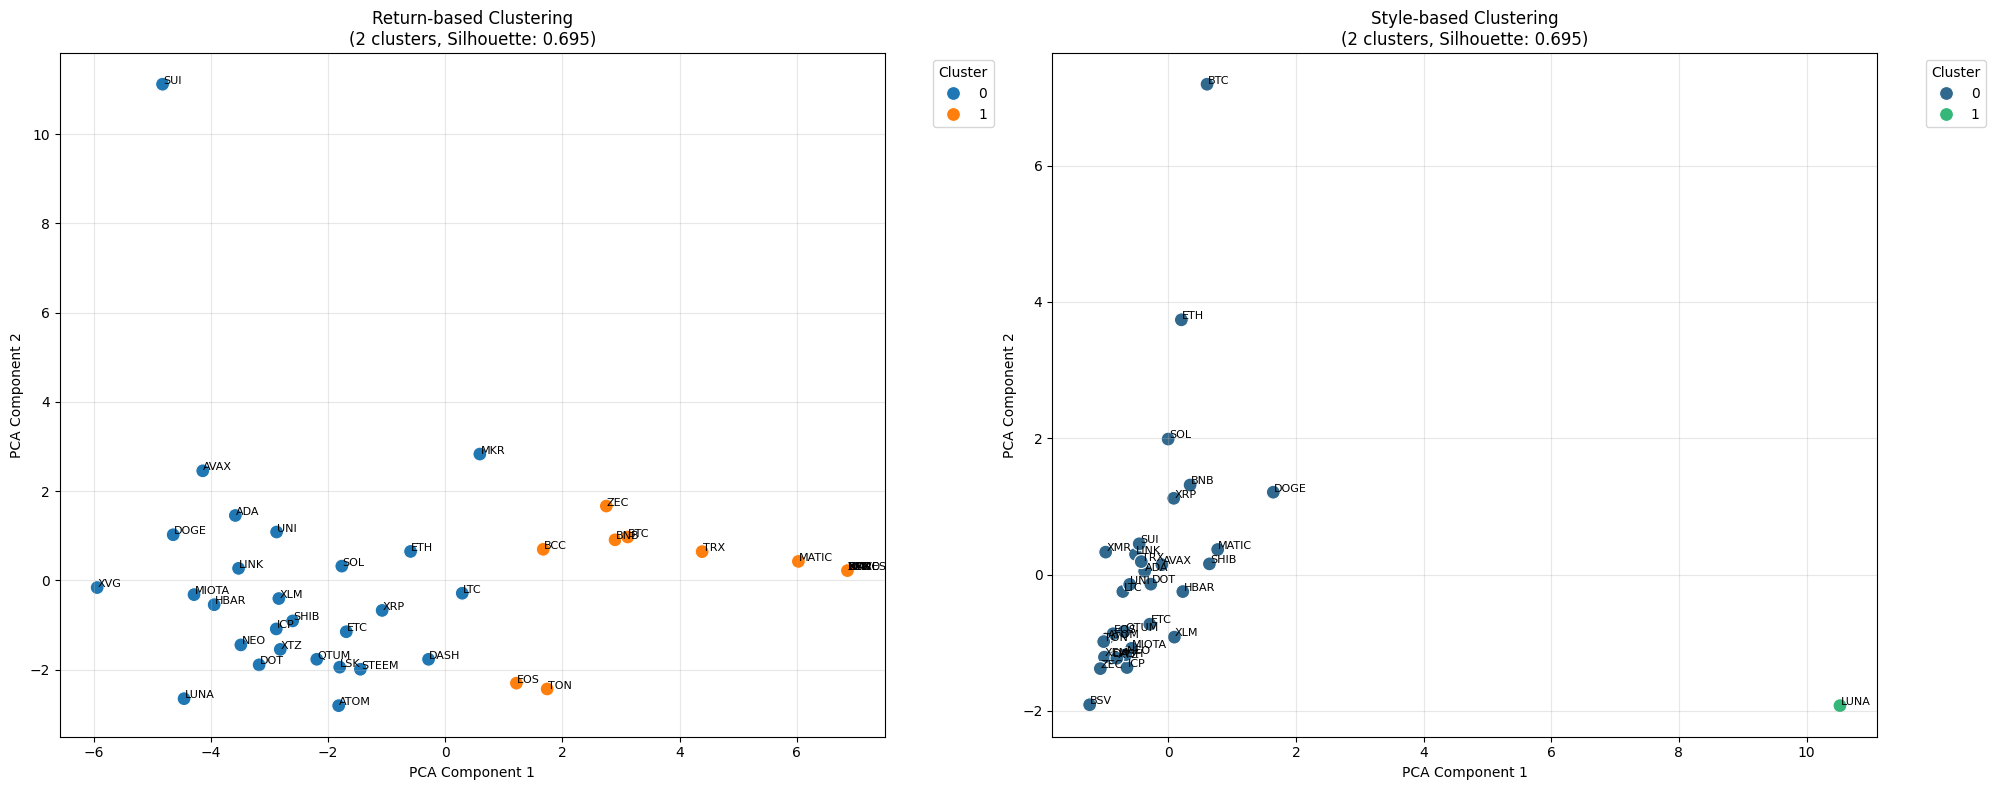

In [90]:
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Prepare data for return-based clustering
X_returns_pca = PCA(n_components=2).fit_transform(X_scaled)

# Create DataFrame for plotting
returns_plot_df = pd.DataFrame({
    'pca1': X_returns_pca[:, 0],
    'pca2': X_returns_pca[:, 1],
    'symbol': X.index,
    'cluster': res1['cluster'].values
})

# Plot return-based clustering
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Return-based clustering plot
sns.scatterplot(
    x='pca1', y='pca2',
    hue='cluster',
    data=returns_plot_df,
    palette='tab10',
    s=100,
    ax=axes[0]
)

# Add symbol labels for return-based
for i, row in returns_plot_df.iterrows():
    axes[0].text(row['pca1']+0.01, row['pca2']+0.01, row['symbol'], fontsize=8)

axes[0].set_title(f'Return-based Clustering\n({best_num_clusters} clusters, Silhouette: {best:.3f})')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

# Prepare data for style-based clustering
X_style_pca = PCA(n_components=2).fit_transform(X_style_scaled)

# Create DataFrame for plotting
style_plot_df = pd.DataFrame({
    'pca1': X_style_pca[:, 0],
    'pca2': X_style_pca[:, 1],
    'symbol': symbols.values,
    'cluster': res2['cluster'].values
})

# Plot style-based clustering
sns.scatterplot(
    x='pca1', y='pca2',
    hue='cluster',
    data=style_plot_df,
    palette='viridis',
    s=100,
    ax=axes[1]
)

# Add symbol labels for style-based
for i, row in style_plot_df.iterrows():
    axes[1].text(row['pca1']+0.01, row['pca2']+0.01, row['symbol'], fontsize=8)

axes[1].set_title(f'Style-based Clustering\n({best_num_clusters} clusters, Silhouette: {max(silhouette_scores):.3f})')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()